In [262]:
import polars as pl

In [263]:
FILTER = "TOMATOES"
# FILTER = "EMERALDS"

DAY = 1

In [264]:

# Quotes (order book snapshots)
quotes = pl.read_csv(
    f"data/orders_day{DAY}.csv",
    separator=";",
    null_values=[""]
)


# Trades
trades = pl.read_csv(
    f"data/trades_day{DAY}.csv",
    separator=";",
    null_values=[""]
)



quotes = quotes.filter(pl.col("product")==FILTER)
trades = trades.filter(pl.col("symbol")==FILTER)

print(quotes.head())
print(trades.head())

shape: (5, 17)
┌─────┬───────────┬──────────┬─────────────┬───┬─────────────┬────────────┬───────────┬────────────┐
│ day ┆ timestamp ┆ product  ┆ bid_price_1 ┆ … ┆ ask_price_3 ┆ ask_volume ┆ mid_price ┆ profit_and │
│ --- ┆ ---       ┆ ---      ┆ ---         ┆   ┆ ---         ┆ _3         ┆ ---       ┆ _loss      │
│ i64 ┆ i64       ┆ str      ┆ i64         ┆   ┆ i64         ┆ ---        ┆ f64       ┆ ---        │
│     ┆           ┆          ┆             ┆   ┆             ┆ i64        ┆           ┆ f64        │
╞═════╪═══════════╪══════════╪═════════════╪═══╪═════════════╪════════════╪═══════════╪════════════╡
│ -1  ┆ 0         ┆ TOMATOES ┆ 4999        ┆ … ┆ null        ┆ null       ┆ 5006.0    ┆ 0.0        │
│ -1  ┆ 100       ┆ TOMATOES ┆ 5000        ┆ … ┆ null        ┆ null       ┆ 5006.5    ┆ 0.0        │
│ -1  ┆ 200       ┆ TOMATOES ┆ 5000        ┆ … ┆ null        ┆ null       ┆ 5006.5    ┆ 0.0        │
│ -1  ┆ 300       ┆ TOMATOES ┆ 5000        ┆ … ┆ null        ┆ null       ┆ 

In [265]:
quotes = quotes.with_columns([
    pl.col("timestamp").cast(pl.Int64),
    pl.col("mid_price").cast(pl.Float64)
])

trades = trades.with_columns([
    pl.col("timestamp").cast(pl.Int64),
    pl.col("price").cast(pl.Float64),
    pl.col("quantity").cast(pl.Int64)
])

In [266]:
quotes = quotes.with_columns([
    pl.col("bid_price_1").alias("best_bid"),
    pl.col("ask_price_1").alias("best_ask"),
    (pl.col("ask_price_1") - pl.col("bid_price_1")).alias("spread")
])

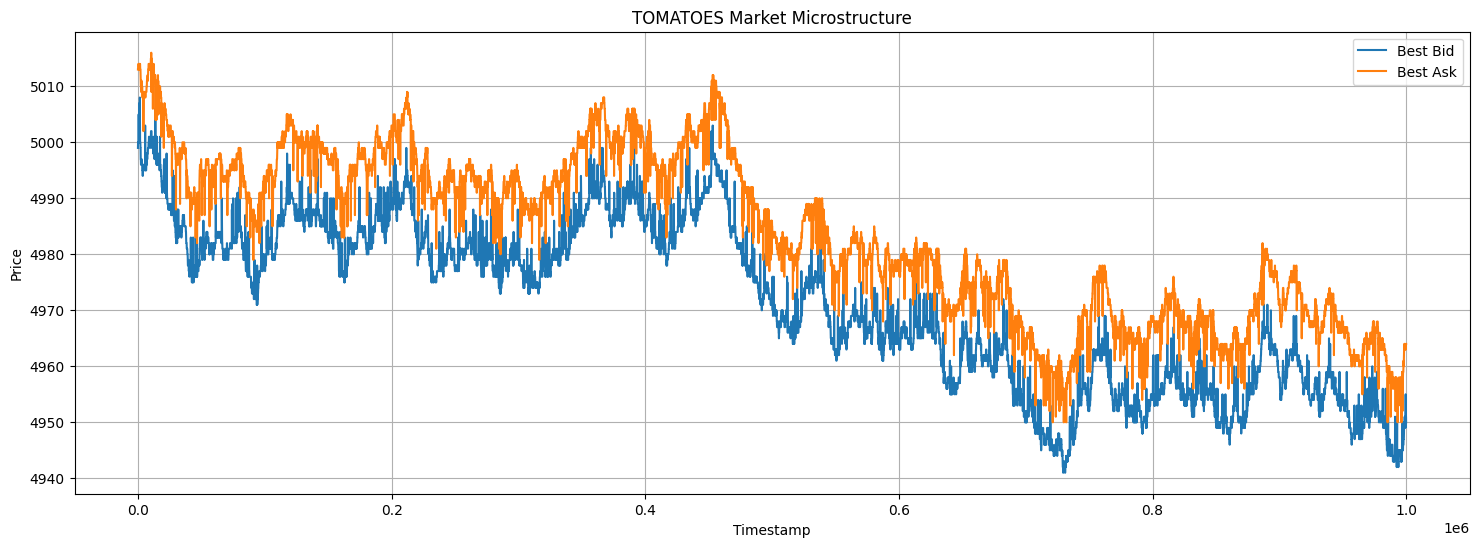

In [267]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

# # Order book lines
plt.plot(quotes["timestamp"], quotes["best_bid"], label="Best Bid")
plt.plot(quotes["timestamp"], quotes["best_ask"], label="Best Ask")
# plt.plot(quotes["timestamp"], quotes["mid_price"], label="Mid Price")

# Trades (scatter)
# plt.scatter(
#     trades["timestamp"],
#     trades["price"],
#     s=trades["quantity"] * 10,
#     marker="o",
#     label="Trades"
# )

plt.title(f"{FILTER} Market Microstructure")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

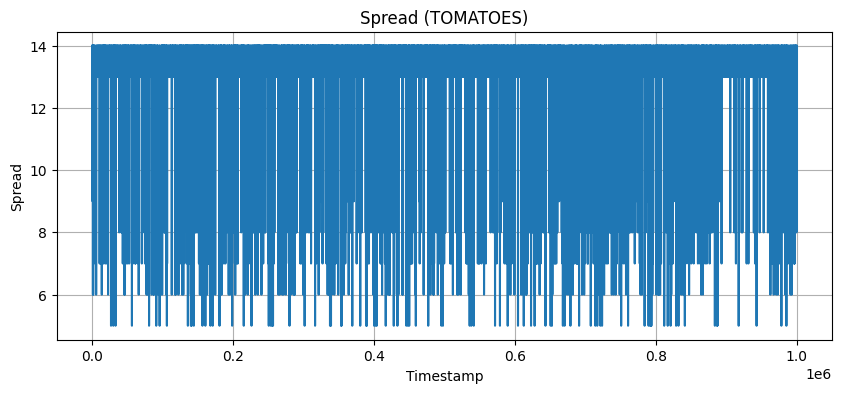

In [268]:
plt.figure(figsize=(10, 4))

plt.plot(quotes["timestamp"], quotes["spread"])

plt.title(f"Spread ({FILTER})")
plt.xlabel("Timestamp")
plt.ylabel("Spread")

plt.grid()
plt.show()

In [269]:
quotes_sorted = quotes.sort("timestamp")
trades_sorted = trades.sort("timestamp")

joined = trades_sorted.join_asof(
    quotes_sorted,
    on="timestamp",
    strategy="backward"
)

joined = joined.with_columns([
    pl.when(pl.col("price") >= pl.col("best_ask"))
      .then(pl.lit("BUY"))
      .when(pl.col("price") <= pl.col("best_bid"))
      .then(pl.lit("SELL"))
      .otherwise(pl.lit("MID"))
      .alias("trade_side")
])

Readable log written to: 59821/59821_readable.log
TRADING LOG ANALYSIS

Total rows loaded : 4000
Products          : ['EMERALDS', 'TOMATOES']
Timestamp range   : 0 – 199900
Days in log       : [-1]

--- Per-product summary ---
shape: (2, 12)
┌──────────┬───────┬────────────┬────────────┬───┬────────────┬──────────┬────────────┬────────────┐
│ product  ┆ ticks ┆ final_pnl  ┆ min_pnl    ┆ … ┆ avg_mid    ┆ std_mid  ┆ avg_bid_vo ┆ avg_ask_vo │
│ ---      ┆ ---   ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---      ┆ l          ┆ l          │
│ str      ┆ u32   ┆ f64        ┆ f64        ┆   ┆ f64        ┆ f64      ┆ ---        ┆ ---        │
│          ┆       ┆            ┆            ┆   ┆            ┆          ┆ f64        ┆ f64        │
╞══════════╪═══════╪════════════╪════════════╪═══╪════════════╪══════════╪════════════╪════════════╡
│ EMERALDS ┆ 2000  ┆ 1050.0     ┆ 0.0        ┆ … ┆ 10000.002  ┆ 0.687191 ┆ 12.4295    ┆ 12.4275    │
│ TOMATOES ┆ 2000  ┆ 1338.70312 ┆ -65.234375 ┆ … ┆ 

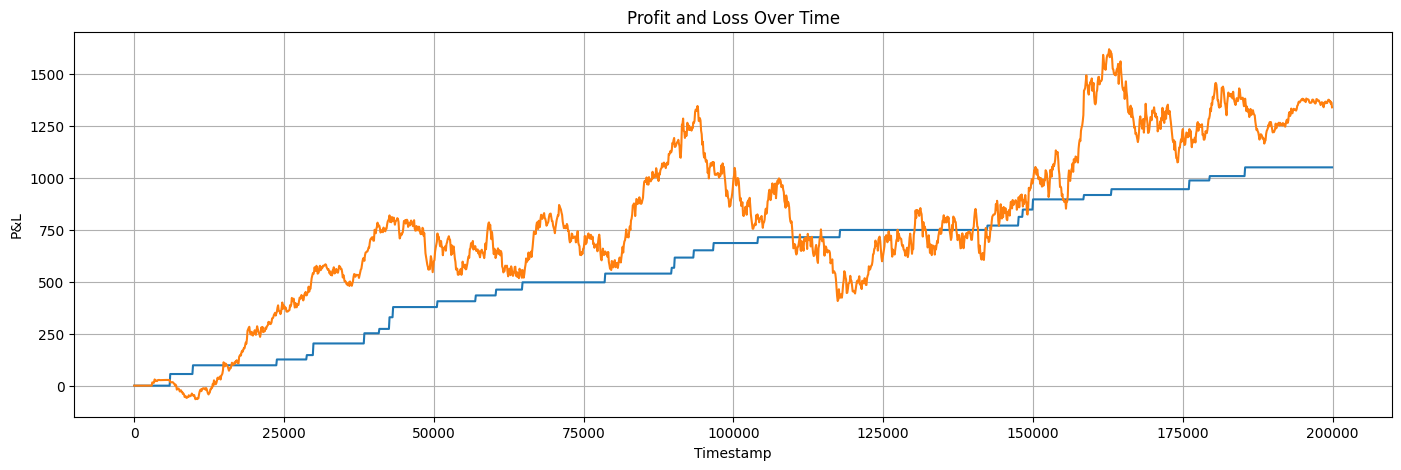

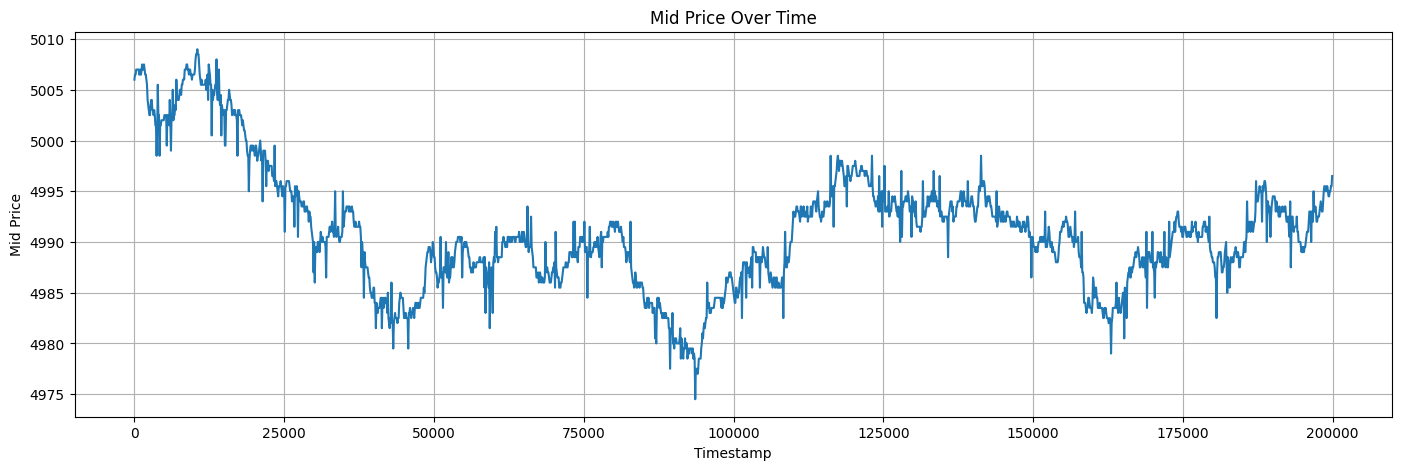

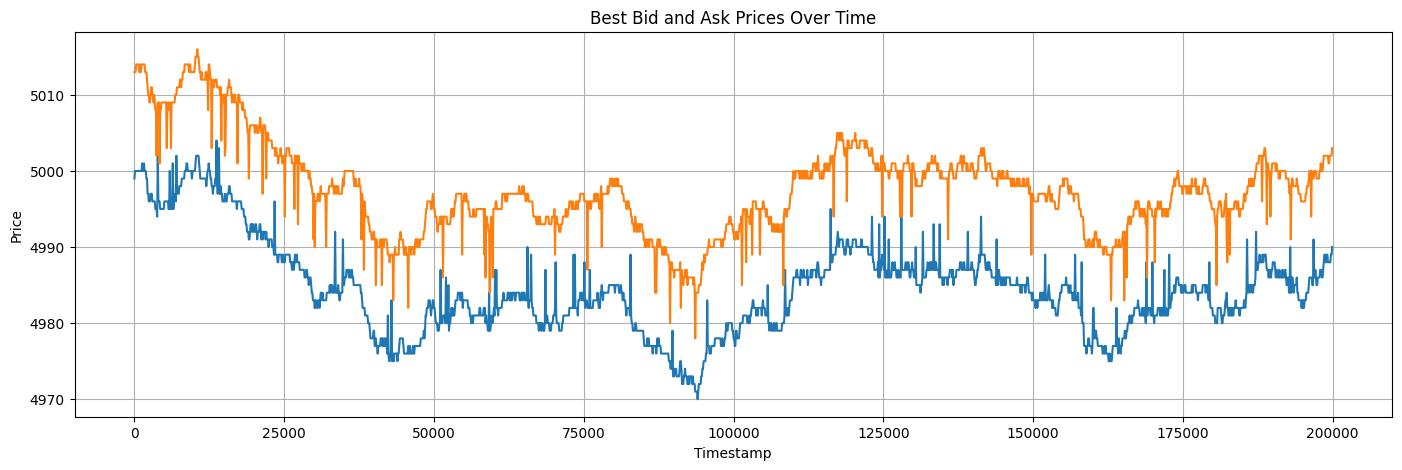

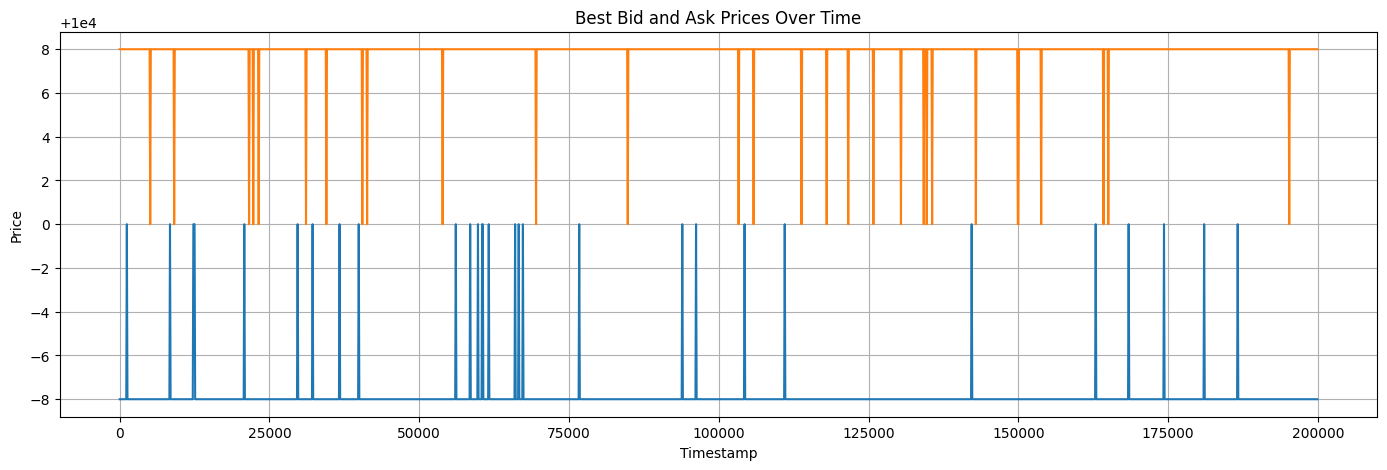

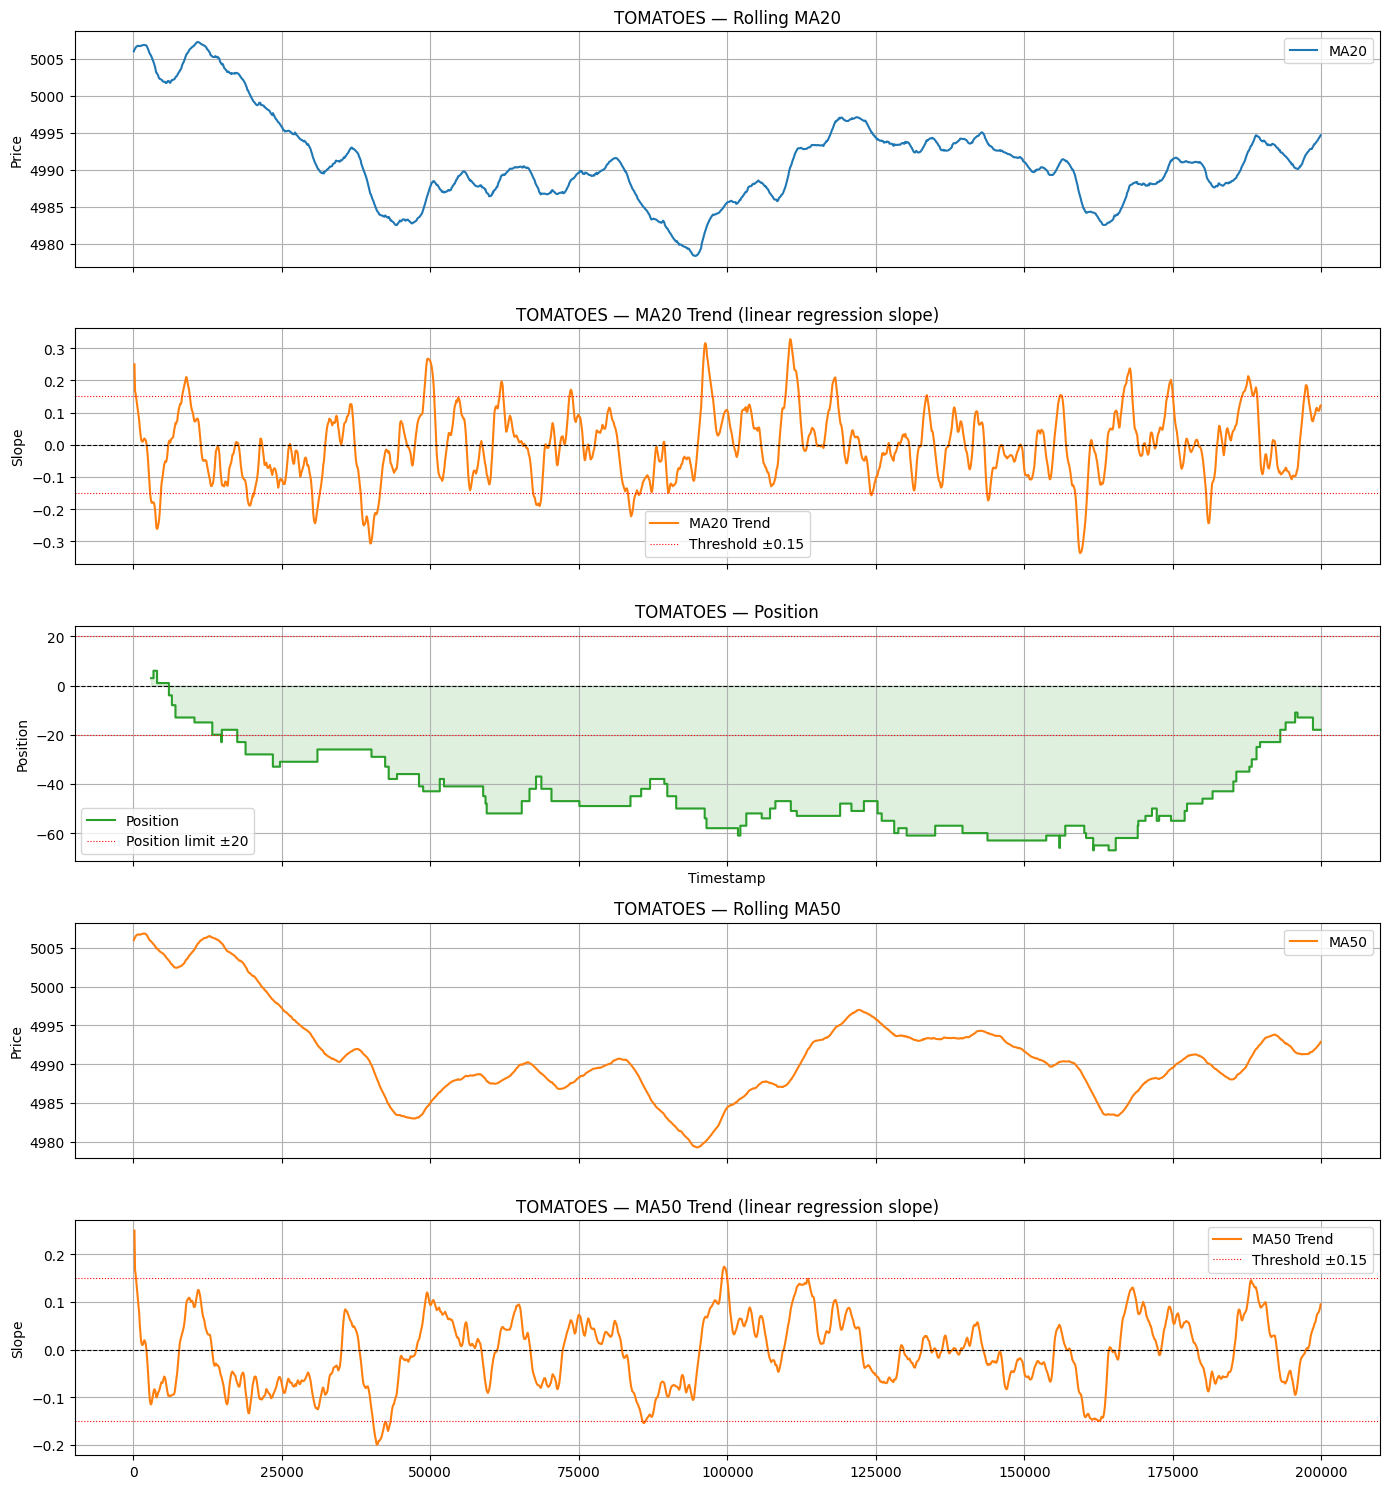


Enriched CSV saved to: 59821/59821_enriched


In [270]:
import polars as pl
import json
import re
import sys
import json
import argparse
from pathlib import Path
from io import StringIO
import matplotlib.pyplot as plt

def parse_log_file(path: str) -> pl.DataFrame:
    """
    Parse a trading log file (JSON with embedded CSV activitiesLog) into a Polars DataFrame.
    Supports both .json log files and raw .csv/.log files.
    """
    with open(path, "r") as f:
        content = f.read().strip()

    # Try JSON format first (log file wraps CSV in activitiesLog key)
    csv_text = None
    try:
        data = json.loads(content)
        csv_text = data.get("activitiesLog", "")
    except json.JSONDecodeError:
        # Might be raw CSV or a JSON-lines file — try extracting activitiesLog from first line
        first_line = content.split("\n")[0]
        try:
            data = json.loads(first_line)
            csv_text = data.get("activitiesLog", "")
        except json.JSONDecodeError:
            # Treat entire file as raw CSV
            csv_text = content

    if not csv_text:
        raise ValueError("No CSV data found in log file.")

    df = pl.read_csv(
        StringIO(csv_text),
        separator=";",
        null_values=[""],
        infer_schema_length=1000,
    )
    return df


def parse_trader_data(data: dict) -> pl.DataFrame:
    """Extract traderData fields from lambda logs into a DataFrame."""
    records = []
    for entry in data.get("logs", []):
        ts = entry.get("timestamp")
        lambda_log = entry.get("lambdaLog", "")
        
        # Extract traderData JSON from the log line
        match = re.search(r'traderData:\s*(\{.*\})', lambda_log)
        if match:
            try:
                td = json.loads(match.group(1))
                records.append({
                    "timestamp": ts,
                    "tomatoes_ma20": td.get("tomatoes_ma20"),
                    "tomatoes_ma20_trend": td.get("tomatoes_ma20_trend"),
                    "tomatoes_ma50": td.get("tomatoes_ma50"),
                    "tomatoes_ma50_trend": td.get("tomatoes_ma50_trend"),
                    "round_count": td.get("round_count"),
                })
            except json.JSONDecodeError:
                continue

    if not records:
        return pl.DataFrame()

    return pl.DataFrame(records).with_columns([
        pl.col("timestamp").cast(pl.Float64),
        pl.col("tomatoes_ma20").cast(pl.Float64),
        pl.col("tomatoes_ma20_trend").cast(pl.Float64),
    ])


def parse_positions(data: dict) -> pl.DataFrame:
    """Extract position data from lambda logs into a DataFrame."""
    records = []
    for entry in data.get("logs", []):
        ts = entry.get("timestamp")
        lambda_log = entry.get("lambdaLog", "")

        match = re.search(r'Position:\s*(\{.*?\})', lambda_log)
        if match:
            try:
                positions = json.loads(match.group(1).replace("'", '"'))
                record = {"timestamp": float(ts)}
                for product, pos in positions.items():
                    record[f"position_{product}"] = float(pos)
                records.append(record)
            except (json.JSONDecodeError, ValueError):
                continue

    return pl.DataFrame(records) if records else pl.DataFrame()

def plot_trader_data(td_df: pl.DataFrame, pos_df: pl.DataFrame) -> None:
    if td_df.is_empty():
        print("No traderData found in logs.")
        return

    fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)
    ax1, ax2, ax3, ax4, ax5 = axes

    # --- MA20 ---
    ma20_df = td_df.filter(pl.col("tomatoes_ma20").is_not_null())
    ax1.plot(ma20_df["timestamp"], ma20_df["tomatoes_ma20"], label="MA20", color="tab:blue")
    ax1.set_title("TOMATOES — Rolling MA20")
    ax1.set_ylabel("Price")
    ax1.legend()
    ax1.grid()

    # --- Trend ---
    trend_df = td_df.filter(pl.col("tomatoes_ma20_trend").is_not_null())
    ax2.plot(trend_df["timestamp"], trend_df["tomatoes_ma20_trend"], label="MA20 Trend", color="tab:orange")
    ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax2.axhline(0.15, color="red", linewidth=0.8, linestyle=":", label="Threshold ±0.15")
    ax2.axhline(-0.15, color="red", linewidth=0.8, linestyle=":")
    ax2.set_title("TOMATOES — MA20 Trend (linear regression slope)")
    ax2.set_ylabel("Slope")
    ax2.legend()
    ax2.grid()

    # --- Position ---
    if not pos_df.is_empty() and "position_TOMATOES" in pos_df.columns:
        pos = pos_df.filter(pl.col("position_TOMATOES").is_not_null())
        ax3.plot(pos["timestamp"], pos["position_TOMATOES"], label="Position", color="tab:green", drawstyle="steps-post")
        ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax3.axhline(20, color="red", linewidth=0.8, linestyle=":", label="Position limit ±20")
        ax3.axhline(-20, color="red", linewidth=0.8, linestyle=":")
        ax3.fill_between(pos["timestamp"].to_list(), pos["position_TOMATOES"].to_list(), 
                         step="post", alpha=0.15, color="tab:green")
    ax3.set_title("TOMATOES — Position")
    ax3.set_xlabel("Timestamp")
    ax3.set_ylabel("Position")
    ax3.legend()
    ax3.grid()

    # --- MA50 ---
    ma50_df = td_df.filter(pl.col("tomatoes_ma50").is_not_null())
    ax4.plot(ma50_df["timestamp"], ma50_df["tomatoes_ma50"], label="MA50", color="tab:orange")
    ax4.set_title("TOMATOES — Rolling MA50")
    ax4.set_ylabel("Price")
    ax4.legend()
    ax4.grid()
    # --- Trend ---
    trend_df = td_df.filter(pl.col("tomatoes_ma50_trend").is_not_null())
    ax5.plot(trend_df["timestamp"], trend_df["tomatoes_ma50_trend"], label="MA50 Trend", color="tab:orange")
    ax5.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax5.axhline(0.15, color="red", linewidth=0.8, linestyle=":", label="Threshold ±0.15")
    ax5.axhline(-0.15, color="red", linewidth=0.8, linestyle=":")
    ax5.set_title("TOMATOES — MA50 Trend (linear regression slope)")
    ax5.set_ylabel("Slope")
    ax5.legend()
    ax5.grid()

    plt.tight_layout()
    plt.show()

def clean_and_enrich(df: pl.DataFrame) -> pl.DataFrame:
    """Cast types and add derived columns."""
    # Ensure numeric types
    numeric_cols = [
        "timestamp", "bid_price_1", "bid_volume_1", "bid_price_2", "bid_volume_2",
        "ask_price_1", "ask_volume_1", "ask_price_2", "ask_volume_2",
        "mid_price", "profit_and_loss",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df = df.with_columns(pl.col(col).cast(pl.Float64, strict=False))

    df = df.with_columns([
        # Best bid-ask spread
        (pl.col("ask_price_1") - pl.col("bid_price_1")).alias("spread"),
        # Absolute mid-price change per product (requires sort first)
        pl.col("mid_price").diff().over("product").alias("mid_price_change"),
    ])
    return df


def summary_stats(df: pl.DataFrame) -> pl.DataFrame:
    """Per-product summary statistics."""
    return (
        df.group_by("product")
        .agg([
            pl.len().alias("ticks"),
            pl.col("profit_and_loss").last().alias("final_pnl"),
            pl.col("profit_and_loss").min().alias("min_pnl"),
            pl.col("profit_and_loss").max().alias("max_pnl"),
            pl.col("spread").mean().alias("avg_spread"),
            pl.col("spread").min().alias("min_spread"),
            pl.col("spread").max().alias("max_spread"),
            pl.col("mid_price").mean().alias("avg_mid"),
            pl.col("mid_price").std().alias("std_mid"),
            pl.col("bid_volume_1").mean().alias("avg_bid_vol"),
            pl.col("ask_volume_1").mean().alias("avg_ask_vol"),
        ])
        .sort("product")
    )


def pnl_by_timestamp(df: pl.DataFrame) -> pl.DataFrame:
    """P&L per product per timestamp, pivoted wide."""
    return (
        df.select(["timestamp", "product", "profit_and_loss"])
        .sort("timestamp")
        .pivot(on="product", index="timestamp", values="profit_and_loss")
    )


def spread_over_time(df: pl.DataFrame) -> pl.DataFrame:
    """Spread per product per timestamp."""
    return (
        df.select(["timestamp", "product", "spread"])
        .sort(["product", "timestamp"])
    )


def mid_price_over_time(df: pl.DataFrame) -> pl.DataFrame:
    """Mid price per product per timestamp."""
    return (
        df.select(["timestamp", "product", "mid_price"])
        .sort(["product", "timestamp"])
    )


def detect_pnl_plateau(df: pl.DataFrame, threshold: float = 1.0) -> pl.DataFrame:
    """
    Detect timestamps where P&L stops changing (possible position cap hit).
    Returns rows where |pnl_change| < threshold for each product.
    """
    return (
        df.sort(["product", "timestamp"])
        .with_columns(
            pl.col("profit_and_loss").diff().over("product").alias("pnl_change")
        )
        .filter(
            (pl.col("pnl_change").abs() < threshold) & pl.col("pnl_change").is_not_null()
        )
        .select(["timestamp", "product", "profit_and_loss", "pnl_change"])
    )


def print_pnl_summary(df: pl.DataFrame) -> None:
    """Print a summary of P&L statistics."""
    tomatoes = df.filter(pl.col("product") == "TOMATOES")
    emeralds = df.filter(pl.col("product") == "EMERALDS")
    plt.figure(figsize=(17, 5))
    plt.plot(emeralds["timestamp"], emeralds["profit_and_loss"])
    plt.plot(tomatoes["timestamp"], tomatoes["profit_and_loss"])
    plt.title("Profit and Loss Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("P&L")
    plt.grid()
    plt.show()

def print_mid_price_tomatoes(df: pl.DataFrame) -> None:
    tomatoes = df.filter(pl.col("product") == "TOMATOES")
    plt.figure(figsize=(17, 5))
    plt.plot(tomatoes["timestamp"], tomatoes["mid_price"])
    plt.title("Mid Price Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Mid Price")
    plt.grid()
    plt.show()

def print_best_bid_ask_tomatoes(df: pl.DataFrame) -> None:
    tomatoes = df.filter(pl.col("product") == "TOMATOES")
    plt.figure(figsize=(17, 5))
    plt.plot(tomatoes["timestamp"], tomatoes["bid_price_1"], label="Best Bid")
    plt.plot(tomatoes["timestamp"], tomatoes["ask_price_1"], label="Best Ask")
    plt.title("Best Bid and Ask Prices Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.grid()
    plt.show()

def print_best_bid_ask_emeralds(df: pl.DataFrame) -> None:
    emeralds = df.filter(pl.col("product") == "EMERALDS")
    plt.figure(figsize=(17, 5))
    plt.plot(emeralds["timestamp"], emeralds["bid_price_1"], label="Best Bid")
    plt.plot(emeralds["timestamp"], emeralds["ask_price_1"], label="Best Ask")
    plt.title("Best Bid and Ask Prices Over Time")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.grid()
    plt.show()

def print_report(df: pl.DataFrame) -> None:
    """Print a human-readable analysis report to stdout."""
    print("=" * 60)
    print("TRADING LOG ANALYSIS")
    print("=" * 60)

    print(f"\nTotal rows loaded : {len(df)}")
    print(f"Products          : {df['product'].unique().to_list()}")
    print(f"Timestamp range   : {int(df['timestamp'].min())} – {int(df['timestamp'].max())}")
    print(f"Days in log       : {df['day'].unique().to_list()}")

    print("\n--- Per-product summary ---")
    print(summary_stats(df))

    print("\n--- P&L pivot (first 10 rows) ---")
    print(pnl_by_timestamp(df).head(10))

    print("\n--- P&L plateaus (possible position cap) ---")
    plateaus = detect_pnl_plateau(df)
    if len(plateaus) > 0:
        print(plateaus.head(10))
    else:
        print("None detected.")


def pretty_print_log(input_path: str, output_path: str | None = None):
    text = Path(input_path).read_text(encoding="utf-8")

    # Parse outer JSON
    data = json.loads(text)

    # Unescape activitiesLog (literal \n -> real newlines)
    activities = data.get("activitiesLog", "")
    activities_clean = activities.replace("\\n", "\n").replace("\\t", "\t")

    # Pretty-print logs array
    logs = data.get("logs", [])

    out_path = output_path or Path(input_path).with_suffix(".readable.log")

    with open(out_path, "w", encoding="utf-8") as f:
        # ── Header ────────────────────────────────────────────────────────────
        f.write(f"submissionId: {data.get('submissionId', 'N/A')}\n")
        f.write("=" * 70 + "\n\n")

        # ── Activities log (the CSV) ──────────────────────────────────────────
        f.write("ACTIVITIES LOG\n")
        f.write("-" * 70 + "\n")
        f.write(activities_clean)
        f.write("\n\n")

        # ── Lambda logs per timestamp ─────────────────────────────────────────
        f.write("LAMBDA LOGS\n")
        f.write("-" * 70 + "\n")
        for entry in logs:
            ts = entry.get("timestamp", "?")
            lambda_log = entry.get("lambdaLog", "").strip()
            sandbox_log = entry.get("sandboxLog", "").strip()
            f.write(f"\n[t={ts}]\n")
            if lambda_log:
                for line in lambda_log.splitlines():
                    f.write(f"  {line}\n")
            if sandbox_log:
                f.write(f"  [sandbox] {sandbox_log}\n")

    print(f"Readable log written to: {out_path}")
    return str(out_path)



# ---------------------------------------------------------------------------
# Entry point
# ---------------------------------------------------------------------------

Version = 59821

if __name__ == "__main__":
    path = f"{Version}/{Version}.log"

    try:
        df_raw = parse_log_file(path)
    except FileNotFoundError:
        print(f"File not found: {path}")
        sys.exit(1)

    pretty_print_log(path, output_path=f"{Version}/{Version}_readable.log")
    df = clean_and_enrich(df_raw)
    print_report(df)
    print_pnl_summary(df)
    print_mid_price_tomatoes(df)
    print_best_bid_ask_tomatoes(df)
    print_best_bid_ask_emeralds(df)

    # Parse and plot traderData
    raw_data = json.loads(Path(path).read_text(encoding="utf-8"))
    td_df = parse_trader_data(raw_data)
    pos_df = parse_positions(raw_data)
    plot_trader_data(td_df, pos_df)

    # Optionally export enriched data
    out_csv = path.replace(".log", "_enriched").replace(".json", "_enriched")
    df_tomatoes = df.filter(pl.col("product") == "TOMATOES")
    df_tomatoes.write_csv(out_csv+".tomatoes.csv")
    df_emeralds = df.filter(pl.col("product") == "EMERALDS")
    df_emeralds.write_csv(out_csv+".emeralds.csv")
    print(f"\nEnriched CSV saved to: {out_csv}")